In [1]:
# Importing numpy and pandas
import numpy as np
import pandas as pd
import time


In [2]:
# Generating Demo Data

np.random.seed(86)

# Number of VMs
num_vms = 20
num_resources = 5  # CPU, RAM, NET, STORAGE, IO

# Baseline Power of the VM
vm_power = np.linspace(0.5, 2.5, num_vms) + np.random.normal(0, 0.1, num_vms)

# Cost proportional to power of the VM but with some variance
c = 3 + 2.0 * vm_power + np.random.normal(0, 0.2, num_vms)
c = np.clip(c, 2, None)


# Energy score
p = 0.7 + 0.1 * vm_power + np.random.normal(0, 0.03, num_vms)
p = np.clip(p, 0.5, 1.2)


# Resource matrix
A = np.zeros((num_vms, num_resources))

# CPU score
A[:, 0] = 2 * vm_power + np.random.normal(0, 0.3, num_vms)
A[:, 0] = np.clip(A[:, 0], 1, 8)

# RAM score
A[:, 1] = 6 * vm_power + np.random.normal(0, 1.0, num_vms)
A[:, 1] = np.clip(A[:, 1], 2, 32)

# Network score
A[:, 2] = 1.0 * vm_power + np.random.normal(0, 0.1, num_vms)
A[:, 2] = np.clip(A[:, 2], 0.5, 5)

# Storage score
A[:, 3] = 40 * vm_power + np.random.normal(0, 5, num_vms)
A[:, 3] = np.clip(A[:, 3], 20, 200)

# IO throughput score
A[:, 4] = 3 * vm_power + np.random.normal(0, 0.5, num_vms)
A[:, 4] = np.clip(A[:, 4], 1, 10)



# Smaller/cheaper VMs tend to be available in larger quantities
u = np.random.randint(5, 20, num_vms)


# Demand
D = np.array([
    50,   # CPU cores
    180,  # RAM
    15,   # Network
    800,  # Storage
    40    # IO
])




eta = 1.0
P = 5.0      # penalty
lam = 0.5    # integer-pull rate


# Final Params generated
pd.DataFrame({
    "Cost c_j": c,
    "Energy p_j": p,
    "CPU": A[:, 0],
    "RAM": A[:, 1],
    "NET": A[:, 2],
    "STOR": A[:, 3],
    "IO": A[:, 4],
    "Upper Bound": u
})


,Cost c_j,Energy p_j,CPU,RAM,NET,STOR,IO,Upper Bound
0,3.792752,0.728379,1.000000,3.247059,0.535931,21.095943,1.484700,18
1,4.229819,0.781137,1.403422,4.401140,0.691043,20.000000,1.534318,15
2,5.038737,0.771130,1.354524,4.819909,0.698061,33.890589,2.145724,13
3,4.629686,0.725972,1.016386,3.881416,0.832769,27.965601,2.410520,7
4,5.080708,0.820820,1.923230,6.054588,0.848149,42.265846,2.074807,17
5,4.680184,0.811244,1.503903,5.901492,0.780473,35.936285,3.432756,15
6,4.836725,0.756728,1.283574,7.214089,0.975351,51.611361,3.249333,18
7,5.858942,0.871293,2.984624,8.454383,1.476902,39.208566,4.394099,5
8,5.937329,0.869235,2.376712,9.318282,1.385929,61.745298,3.994338,13
9,5.891274,0.817847,3.622935,8.099580,1.482457,64.249037,5.223466,7


In [3]:
def C_linear(x):
    return np.sum(c * x)  # linear VM cost

def C_energy(x):
    return eta * np.sum(p * x**1.4)  # nonlinear energy term

def C_int(x):
    return lam * np.sum(1 - np.cos(2 * np.pi * x))  # integer-promotion

def constraint_shortfall(x):
    return np.maximum(0, D - A.T @ x)  # unmet demand

def C_penalty(x):
    s = constraint_shortfall(x)
    return P * np.sum(s**2)  # constraint penalty

def f(x):
    return C_linear(x) + C_energy(x) + C_int(x) + C_penalty(x)



In [4]:
def grad(x):
    g = np.zeros_like(x)

    # Gradient of linear cost is just the cost vector
    g += c

    # Gradient of nonlinear energy term
    g += 1.4 * eta * p * (x**0.4)

    # Gradient of the integer-promoting penalty
    g += 2 * np.pi * lam * np.sin(2 * np.pi * x)

    # Constraint penalty gradient
    s = constraint_shortfall(x)
    g -= 2 * P * (A @ s)

    return g


In [5]:
# Ensuring that x remains within valid bounds:
def projection(x):
    return np.clip(x, 0, u)


In [6]:


P0 = 1.0      # initial penalty
beta = 5.0    # scaling factor for penalty
max_outer = 1000
eps = 1e-10

def penalized_objective(x, P):
    return C_linear(x) + C_energy(x) + C_int(x) + P * np.sum(constraint_shortfall(x)**2)

def penalized_grad(x, P):
    g = c + 1.4 * eta * p * (x**0.4)
    g += 2 * np.pi * lam * np.sin(2 * np.pi * x)
    s = constraint_shortfall(x)
    g -= 2 * P * (A @ s)
    return g

def solve_penalized(P, x_init=None, alpha=0.001, iters=2000, record_every=20):
    x = np.zeros(num_vms) if x_init is None else x_init.copy()
    history = []
    for it in range(iters):
        x = x - alpha * penalized_grad(x, P)
        x = np.clip(x, 0, u)
        if it % record_every == 0:
            history.append(penalized_objective(x, P))
    return x, history



P = P0
x = np.zeros(num_vms)
convergence = []   # flattened inner histories for plotting
penalty_levels = []  # track P at outer iterations
outer_iter = 0

for outer in range(max_outer):
    outer_iter = outer
    x, inner_hist = solve_penalized(P, x_init=x, alpha=0.001, iters=2000, record_every=20)
    convergence.extend(inner_hist)
    penalty_levels.append(P)

    s = constraint_shortfall(x)
    if np.all(s < eps):
        break
    P *= beta

final_P = P
final_x = x
final_shortfall = constraint_shortfall(final_x)
final_obj = penalized_objective(final_x, final_P)


In [7]:
# Tabular summary of final allocations and VM specs
results = pd.DataFrame({
    "VM Type": np.arange(1, num_vms + 1),
    "x_j (allocation)": final_x,
    "Rounded x_j": np.round(final_x).astype(int),
    "Cost c_j": c,
    "Energy p_j": p,
    "CPU": A[:, 0],
    "RAM": A[:, 1],
    "NET": A[:, 2],
    "STOR": A[:, 3],
    "IO": A[:, 4],
    "Upper Bound u_j": u
})


print("Outer iterations run:", outer_iter + 1)
print("Final penalty P:", final_P)
print("Final objective (penalized):", final_obj)
print("Max shortfall per resource:", final_shortfall.max())
results


Outer iterations run: 2
Final penalty P: 5.0
Final objective (penalized): 178.14338512845484
Max shortfall per resource: 0.0


,VM Type,x_j (allocation),Rounded x_j,Cost c_j,Energy p_j,CPU,RAM,NET,STOR,IO,Upper Bound u_j
0,1,4.747438,5,3.792752,0.728379,1.000000,3.247059,0.535931,21.095943,1.484700,18
1,2,3.835353,4,4.229819,0.781137,1.403422,4.401140,0.691043,20.000000,1.534318,15
2,3,0.870738,1,5.038737,0.771130,1.354524,4.819909,0.698061,33.890589,2.145724,13
3,4,0.017525,0,4.629686,0.725972,1.016386,3.881416,0.832769,27.965601,2.410520,7
4,5,3.867550,4,5.080708,0.820820,1.923230,6.054588,0.848149,42.265846,2.074807,17
5,6,2.906004,3,4.680184,0.811244,1.503903,5.901492,0.780473,35.936285,3.432756,15
6,7,4.943580,5,4.836725,0.756728,1.283574,7.214089,0.975351,51.611361,3.249333,18
7,8,0.055013,0,5.858942,0.871293,2.984624,8.454383,1.476902,39.208566,4.394099,5
8,9,0.064072,0,5.937329,0.869235,2.376712,9.318282,1.385929,61.745298,3.994338,13
9,10,0.051658,0,5.891274,0.817847,3.622935,8.099580,1.482457,64.249037,5.223466,7


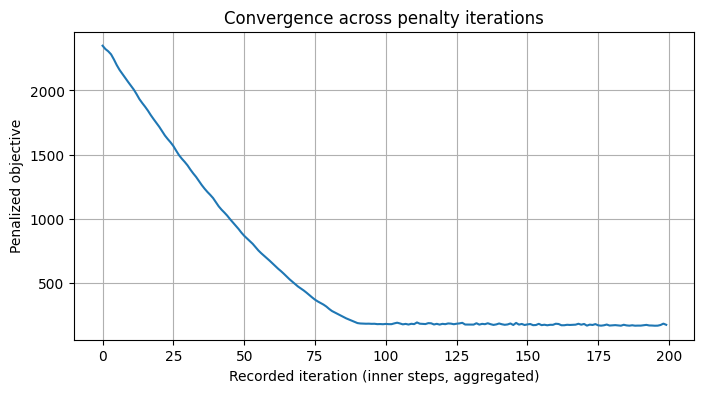

In [8]:
# Plot: convergence of objective value across inner iterations
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(convergence)
plt.xlabel("Recorded iteration (inner steps, aggregated)")
plt.ylabel("Penalized objective")
plt.title("Convergence across penalty iterations")
plt.grid(True)
plt.show()


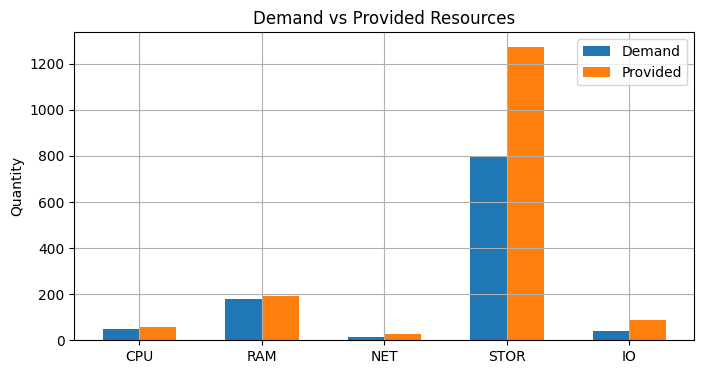

In [9]:
# Visual check: demand vs provided resources (after final allocation)
provided = A.T @ final_x  # provided amount for each resource

plt.figure(figsize=(8,4))
inds = np.arange(len(D))
plt.bar(inds - 0.15, D, width=0.3)              # demand
plt.bar(inds + 0.15, provided, width=0.3)       # provided
plt.xticks(inds, ["CPU","RAM","NET","STOR","IO"])
plt.ylabel("Quantity")
plt.title("Demand vs Provided Resources")
plt.legend(["Demand", "Provided"])
plt.grid(True)
plt.show()


In [10]:
# Shortfall numbers and quick suggestion if any shortfall remains
shortfall = np.maximum(0, D - provided)
print("Shortfall per resource:", shortfall)
if np.all(shortfall < eps):
    print("All demands satisfied within tolerance.")
else:
    print("Some demands unmet. Consider increasing max_outer, beta, or running more inner iterations.")


Shortfall per resource: [0. 0. 0. 0. 0.]
All demands satisfied within tolerance.
